<a href="https://colab.research.google.com/github/lilianabs/ml-algorithms-from-scratch/blob/main/Naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [39]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0,
                           n_classes=2, random_state=42)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (1000, 10)
Shape of target (y): (1000,)


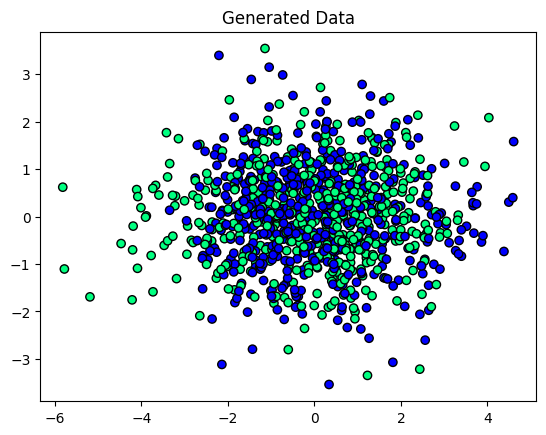

In [40]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
plt.title("Generated Data")
plt.show()

## Implementation (functions)

In [41]:
unique_classes = np.unique(y)
class_1 = unique_classes[0]
class_2 = unique_classes[1]
class_1, class_2

(np.int64(0), np.int64(1))

In [42]:
class_1_indices = np.where(y == class_1)[0]
class_2_indices = np.where(y == class_2)[0]

In [43]:
class_1_col_means = np.mean(X[class_1_indices], axis=0)
class_2_col_means = np.mean(X[class_2_indices], axis=0)

In [44]:
class_1_col_var = np.var(X[class_1_indices], axis=0)
class_2_col_var = np.var(X[class_2_indices], axis=0)

In [45]:
class_1_col_var

array([2.39827262, 1.12767769, 2.44085128, 1.19013837, 1.03676978,
       0.84143976, 1.18099343, 1.10090947, 2.73098617, 1.06767775])

In [46]:
class_1_prior = np.sum(y == class_1) / len(y)
class_2_prior = np.sum(y == class_2) / len(y)

In [47]:
def gaussian_density(x, mean, var):
    """
    Calculates the Gaussian probability density.
    x: the feature value(s) of the new data point
    mean: the mean of the feature for a specific class
    var: the variance of the feature for a specific class
    """
    eps = 1e-4 # Stability to prevent division by zero

    # 1. The coefficient (left side)
    coeff = 1.0 / np.sqrt(2.0 * np.pi * (var + eps))

    # 2. The exponent (right side)
    exponent = np.exp(-((x - mean) ** 2) / (2.0 * (var + eps)))

    return coeff * exponent


## Implementation (class)

In [48]:
class GaussianNaiveBayes:

    def __init__(self):
        self.classes = None
        self.mean = None
        self.var = None
        self.priors = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initialize arrays to store statistics
        # Shape: (number of classes, number of features)
        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        # The "Training" Loop
        for idx, c in enumerate(self.classes):
            # 1. Filter X to get ONLY the rows where the label is 'c'
            X_c = X[y == c]

            # 2. Calculate the mean and variance for every feature in this class
            # Hint: Use axis=0 to calculate down the columns
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)

            # 3. Calculate the prior (fraction of total samples belonging to this class)
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
      # Run _predict_single for every row in X
      y_pred = [self._predict_single(x) for x in X]
      return np.array(y_pred)

    def _predict_single(self, x):
        posteriors = []

        # Calculate the score for every possible class
        for idx, c in enumerate(self.classes):

            # 1. Start with the log of the prior for this class
            log_prior = np.log(self.priors[idx])

            # 2. Calculate the likelihoods for all features
            # Hint: Call the gaussian_density() function we wrote earlier!
            # You will pass in 'x', 'self.mean[idx]', and 'self.var[idx]'
            likelihoods = gaussian_density(x, self.mean[idx], self.var[idx])

            # 3. Calculate the sum of the log likelihoods
            # Hint: np.sum(np.log(likelihoods))
            log_likelihood_sum = np.sum(np.log(likelihoods))

            # 4. Final Score = Log Prior + Log Likelihood Sum
            posterior = log_prior + log_likelihood_sum
            posteriors.append(posterior)

        # Return the class that got the highest score
        # Hint: np.argmax() returns the index of the largest value in a list
        return self.classes[np.argmax(posteriors)]

## Test implementation

In [49]:
nb = GaussianNaiveBayes()
nb.fit(X, y)

In [50]:
y_pred = nb.predict(X)

In [51]:
y_pred

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,